# Assignment 1: Predicting stroke

#### *Authors: Ghanem Ayman, Reszka-Gniecki Michal, Vilhena Alho Shanil, Vircheva Boni*

In this analysis, we aim to predict the likelihood of an individual suffering a stroke using various personal, medical, and lifestyle data. The dataset includes attributes such as age, hypertension, heart disease history, glucose levels, body mass index (BMI), gender, marital status, employment type, residence type and smoking habits. 
By leveraging some of these features, we will develop a machine learning model that (in best case) can accurately predict the occurrence of a stroke. The primary goal is to identify patterns within the data that contribute to stroke risk, offering insights that could support early intervention and prevention strategies. This analysis is part of a broader competition, where teams will be evaluated based on the accuracy of their models.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from scipy.stats import zscore

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, make_scorer, roc_auc_score, accuracy_score
from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from IPython.display import display, Markdown
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real

In [2]:
df = pd.read_csv('train-2.csv')

In [3]:
class DataPreprocessor:
    """
    A class to preprocess data for machine learning models.
    """

    def __init__(self, df):
        """
        Make a copy of the input dataframe.

        Parameters
        ----------
        df : pandas.DataFrame
            The dataframe to preprocess.
        """
        self.df = df.copy()
    
    def age_to_int(self):
        """
        Converts the 'age' column to integer.
        """
        self.df['age'] = self.df['age'].astype(int)
        return self.df

    def drop_not_needed_columns(self):
        if 'stroke' in self.df.columns:
            self.df.loc[(self.df['work_type_children'] == True) & (self.df['stroke'] == True), 'work_type_Govt_job'] = True
            self.df = self.df[self.df['gender_Other'] == 0]
        
        self.df.drop(['gender_Other', 'work_type_Never_worked', 'work_type_children'], axis=1, inplace=True)
        return self.df

    def preprocess_gender(self):
        """
        Processes gender columns.

        Converts 'gender_Female' and 'gender_Male' columns into a single
        'gender' column with binary values: 0 for Female and 1 for Male.
        Filters out rows where 'gender_Other' is 1.
        """
        self.df['gender'] = self.df.apply(
            lambda row: 0 if row['gender_Female'] else 1,
            axis=1
        )
        self.df.drop(['gender_Female', 'gender_Male'], axis=1, inplace=True)
        return self.df
    
    def preprocess_ever_married(self):
        """
        Converts 'ever_married' columns to a single 'ever_married' column.

        The new column has binary values: 1 for Yes and 0 for No.
        """
        self.df['ever_married'] = self.df.apply(
            lambda row: 1 if row['ever_married_Yes'] else 0,
            axis=1
        )
        self.df.drop(['ever_married_No', 'ever_married_Yes'], axis=1, inplace=True)
        return self.df
    
    def preprocess_residence_type(self):
        """
        Converts residence type columns to a single 'residence_type' column.

        The new column has binary values: 0 for Rural and 1 for Urban.
        """
        self.df['residence_type'] = self.df.apply(
            lambda row: 0 if row['Residence_type_Rural'] else 1,
            axis=1
        )
        self.df.drop(['Residence_type_Rural', 'Residence_type_Urban'], axis=1, inplace=True)
        return self.df
    
    def preprocess_work_type(self):
        """
        Converts work type columns and creates a 'work_type_self_employed' column.

        The new column has binary values: 1 if self-employed, else 0.
        """
        self.df['work_type_self_employed'] = self.df.apply(
            lambda row: 1 if row['work_type_Self-employed'] else 0,
            axis=1
        )
        self.df.drop(['work_type_Govt_job', 'work_type_Private',
                      'work_type_Self-employed'], axis=1, inplace=True)
        return self.df
    
    def convert_bool_to_int(self):
        """
        Converts boolean columns to integer type.
        """
        self.df[self.df.select_dtypes(include='bool').columns] = self.df.select_dtypes(include='bool').astype(int)
        return self.df
    
    def drop_columns(self, columns):
        """
        Drops specified columns from the dataframe.

        Parameters
        ----------
        columns : list of str
            List of column names to be dropped.
        """
        self.df.drop(columns=columns, inplace=True)
        return self.df
    
    def add_age_above_60(self):
        """
        Adds a binary 'age_above_60' column.

        The new column has values of 1 if age > 60, else 0.
        """
        self.df['age_above_60'] = self.df['age'].apply(lambda x: 1 if x > 60 else 0)
        return self.df
    
    def add_interaction_terms(self):
        """
        Creates interaction terms based on existing features.

        New columns include:
        - 'age_above_60_hypertension': Product of 'age_above_60' and 'hypertension'
        - 'age_above_60_heart_disease': Product of 'age_above_60' and 'heart_disease'
        - 'hypertension_former_smoker': Product of 'hypertension' and 'smoking_status_formerly smoked'
        """
        self.df['age_above_60_hypertension'] = self.df['age_above_60'] * self.df['hypertension']
        self.df['age_above_60_heart_disease'] = self.df['age_above_60'] * self.df['heart_disease']
        self.df['hypertension_former_smoker'] = self.df['hypertension'] * self.df['smoking_status_formerly smoked']
        return self.df
    
    def categorize_bmi(self):
        """
        Categorizes BMI into 'underweight', 'normal', 'overweight', and 'obese'.

        Creates a new 'bmi_category' column based on the following thresholds:
        - BMI < 18.5: 'underweight'
        - 18.5 <= BMI < 24.9: 'normal'
        - 24.9 <= BMI < 29.9: 'overweight'
        - BMI >= 30: 'obese'
        """
        def categorize(bmi):
            if bmi < 18.5:
                return 'underweight'
            elif 18.5 <= bmi < 24.9:
                return 'normal'
            elif 24.9 <= bmi < 29.9:
                return 'overweight'
            else:
                return 'obese'
        self.df['bmi_category'] = self.df['bmi'].apply(categorize)
        return self.df
    
    def categorize_glucose(self):
        """
        Categorizes glucose levels into 'normal', 'prediabetic', and 'diabetic'.

        Creates a new 'glucose_category' column based on the following thresholds:
        - avg_glucose_level < 140: 'normal'
        - 140 <= avg_glucose_level < 200: 'prediabetic'
        - avg_glucose_level >= 200: 'diabetic'
        """
        def categorize(avg_glucose_level):
            if avg_glucose_level < 140:
                return 'normal'
            elif 140 <= avg_glucose_level < 200:
                return 'prediabetic'
            else:
                return 'diabetic'
        self.df['glucose_category'] = self.df['avg_glucose_level'].apply(categorize)
        return self.df
    
    def encode_categories(self):
        """
        Encodes categorical features for BMI and glucose categories.

        Creates two new columns:
        - 'glucose_category_encoded' with values 0 for 'normal', 1 for 'prediabetic', and 2 for 'diabetic'.
        - 'bmi_category_encoded' with values 0 for 'underweight', 1 for 'normal', 2 for 'overweight', and 3 for 'obese'.
        """
        glucose_mapping = {'normal': 0, 'prediabetic': 1, 'diabetic': 2}
        self.df['glucose_category_encoded'] = self.df['glucose_category'].map(glucose_mapping)
        
        bmi_mapping = {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
        self.df['bmi_category_encoded'] = self.df['bmi_category'].map(bmi_mapping)
        return self.df
    
    def drop_categorical_columns(self):
        """
        Drops the original categorical columns after encoding.
        """
        self.df.drop(['bmi_category', 'glucose_category'], axis=1, inplace=True)
        return self.df
    
    def reindex_columns(self, reference_columns):
        """
        Reindexes dataframe columns to match the training data.

        Adds any missing columns from `reference_columns` with default values of 0.

        Parameters
        ----------
        reference_columns : list of str
            List of column names to ensure consistency with training data.
        """
        self.df = self.df.reindex(columns=reference_columns, fill_value=0)
        return self.df

    def remove_outliers(self):

        #Calculates the Z-scores for each column and keeps rows where its below the threshold for each column independently:
        threshold = 3
        z_scores = np.abs(zscore(self.df[['bmi', 'avg_glucose_level']]))
        self.df = self.df[(z_scores < threshold).all(axis=1)]
        return self.df
    
    def preprocess(self, columns_to_drop, reference_columns):
        """
        Runs the full preprocessing pipeline on the dataframe.

        Parameters
        ----------
        columns_to_drop : list of str
            Columns to drop from the dataframe.
        
        reference_columns : list of str
            List of columns for reindexing to maintain consistency with training data.

        Returns
        -------
        pandas.DataFrame
            The preprocessed dataframe.
        """
    
        self.drop_not_needed_columns()
        self.age_to_int()
        self.preprocess_gender()
        self.preprocess_ever_married()
        self.preprocess_residence_type()
        self.preprocess_work_type()
        self.convert_bool_to_int()
        self.drop_columns(columns_to_drop)
        self.add_age_above_60()
        self.add_interaction_terms()
        self.categorize_bmi()
        self.categorize_glucose()
        self.encode_categories()
        self.drop_categorical_columns()
        self.reindex_columns(reference_columns)

        return self.df


@TODO MICHAL: Please add name of Chat+Link in this format (only if necessary - thats bonis link rn)

[ChatGPT, 2024. Prompt 1: Code Documentation Request](https://chatgpt.com/share/67308835-1074-8000-bcb6-2c183bcaecd0).

In [4]:
processor = DataPreprocessor(df)

In [5]:
df.head(5)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,False,True,...,False,True,False,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,False,...,False,False,True,False,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,False,True,...,False,True,False,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,False,...,False,False,True,False,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,False,...,False,False,True,False,True,False,True,False,False,0


In [6]:
len(df)

33550

We have a dataset with 33,550 entries and the following 22 columns:

#### **Continuous Variables:**
*(= Variables that can have any value within a range)*

- **`id`**: A unique identifier for each person.
- **`age`**: The age of the person.
- **`avg_glucose_level`**: The average glucose level in the person’s blood.
- **`bmi`**: The Body Mass Index of the person (BMI – a measure of body fat).

#### **Binary Variables:**
*(= Variables with only two possible values, often represented as 1/0 or true/false)*

- **`hypertension`**: Indicates if the person has high blood pressure (1) or not (0).
- **`heart_disease`**: Indicates if the person has a history of heart disease (1) or not (0).
- **`gender_Female/Male/Other`**: Represents gender, split into separate True/False indicators for each category (e.g. Female = True or False).
- **`ever_married_No/Yes`**: Indicates whether the person has ever been married or not.
- **`work_type_Govt_job/Never_worked/Private/Self-employed/children`**: Different job types represented with separate True/False indicators.
- **`Residence_type_Rural/Urban`**: Indicates whether the person lives in a rural or urban area.
- **`smoking_status_formerly smoked/never smoked/smokes`**: Represents smoking status with separate True/False indicators.
- **`stroke`**: Indicates if the person has had a stroke (1) or not (0) --> This will be our target variable.

In [7]:
continuous_cols = ['bmi', 'avg_glucose_level', 'age']
binary_cols = ['hypertension', 'heart_disease', 'gender_Female', 'gender_Male',
               'ever_married_No', 'ever_married_Yes', 'work_type_Govt_job',
               'work_type_Private', 'work_type_Self-employed', 'Residence_type_Rural',
               'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked',
               'smoking_status_smokes']

## Data Types and Missing Values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

## In-Depth Data Description

In the output above we can see that there are no missing values in the dataframe. 

However, when we look at the data types, there are a lot of collumns that have booleans as a value. (e.g. booleans can only have 2 values: True and False). In order to apply Machine Learning on this dataset, we have to transform these boolean values into numerical values (e.g. 1 = TRUE, 0 = FALSE). If we have transformed the dataframe into only numerical values, we can apply our EDA and ML models eventually.


In [9]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


## Handling Underrepresented Columns

In this step, we create a filtered dataset containing only patients who have had a stroke and calculate the sum of each feature across these cases to gather an overview:

In [10]:
df_stroke = df.copy()
df_stroke = df[df['stroke'] == 1]

display(df_stroke.sum())

id                                19057595.00
age                                  35433.00
hypertension                           144.00
heart_disease                          110.00
avg_glucose_level                    66927.02
bmi                                  15448.50
gender_Female                          291.00
gender_Male                            226.00
gender_Other                             0.00
ever_married_No                         55.00
ever_married_Yes                       462.00
work_type_Govt_job                      58.00
work_type_Never_worked                   0.00
work_type_Private                      287.00
work_type_Self-employed                171.00
work_type_children                       1.00
Residence_type_Rural                   253.00
Residence_type_Urban                   264.00
smoking_status_formerly smoked         140.00
smoking_status_never smoked            214.00
smoking_status_smokes                   89.00
stroke                            

From this overview, we can see that the columns `gender_Other`, `work_type_Never_worked`, and `work_type_children` are underrepresented or have no stroke cases at all. Therefore, these columns will be removed. Additionally, the one stroke case with `work_type_children` will be reassigned to `work_type_Govt_job` to retain the relevant data.

These steps are handled in the DataPreprocessor class under the *drop_not_needed_columns* function.

In [11]:
df = processor.drop_not_needed_columns()


## Comparison of Stroke vs Non-Stroke Patients for **Continuous Columns**

In the following we generate boxplots to compare the distribution of continuous variables between patients who have had a stroke and those who have not. This visual representation helps identify any significant differences in continuous features, such as age or average glucose level, between the two groups

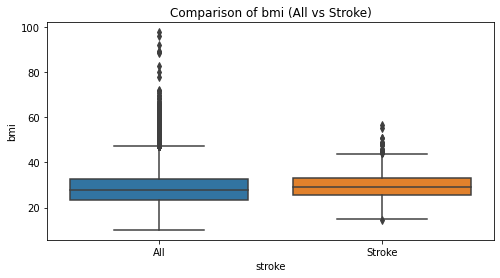

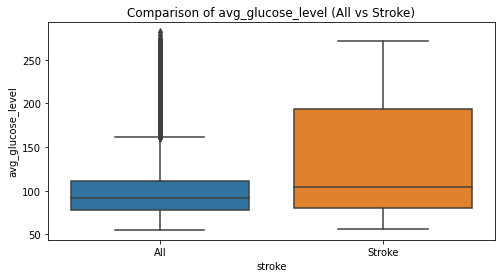

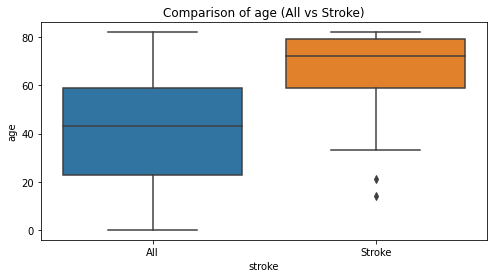

In [12]:
# Boxplots for continuous variables
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.xticks([0, 1], ['All', 'Stroke'])
    plt.ylabel(col)
    plt.show()

[Partially ChatGPT, 2024. Prompt 2: Boxplots by Stroke Status](https://chatgpt.com/share/67308e61-2548-8003-9a1d-3722fda414a9).

***BMI Comparisson (All vs Stroke)***

- We observe from the plot that people that had a stroke tend to have a slightly higher BMI on average compared to the overall population. BMI is associated with increased health risks, one of which may be getting a stroke. However as seen in the plot, because the difference in BMI is not extreme, although it may play an important role, it isn't a dominant factor in this machine learning analysis.

***Average Glucose Level Comparison (All vs Stroke)***

- We observe from the plot that people who had a stroke tend to have significantly higher average glucose levels compared to the overall population. Elevated glucose levels are commonly associated with health conditions like diabetes, which is a known risk factor for stroke. The difference in glucose levels between the stroke and non-stroke groups suggests that high glucose levels could be an important indicator of stroke risk. This indicates that glucose monitoring may be very important in assessing stroke risk.

***Average Age Comparison (All vs Stroke)***
- Age is one of the most significant risk factors for stroke, the older age profile in the "Stroke" group aligns with established medical knowledge that stroke risk increases significantly in older adults. This suggests that age is a key demographic factor to consider for the further analysis.

As we see there are a lot of outliers in the `bmi` and `avg_glucose_level`, because of that we will remove all the extreme outliers, using the Z-schore. The z-score algorithm indicates how many standard deviations a data point is from the mean. Data points with a z-score greater than 3 are considered extreme outliers which is why we remove them.

In [13]:
df = processor.remove_outliers()
display(df)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,True,False,False,True,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,True,False,False,True,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,True,False,False,True,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,True,False,False,True,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,True,False,False,True,True,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,71911,9.0,0,0,109.80,14.5,False,True,True,False,False,False,False,True,False,False,False,False,0
33546,19648,47.0,0,0,88.61,30.8,True,False,False,True,False,True,False,False,True,False,False,False,0
33547,35550,3.0,0,0,89.68,16.2,True,False,True,False,False,False,False,True,False,False,False,False,0
33548,65453,56.0,1,0,82.44,27.8,True,False,False,True,True,False,False,False,True,False,False,True,0


## Comparison of Stroke vs Non-Stroke Patients for **Binary Columns**

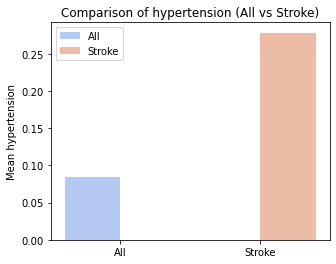

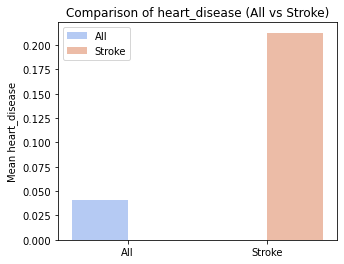

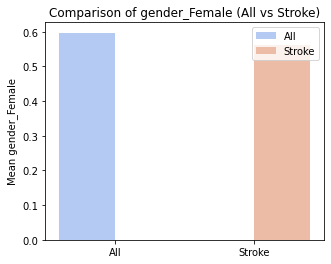

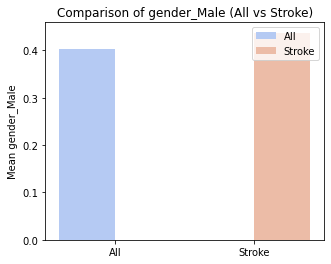

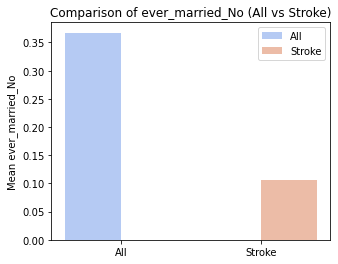

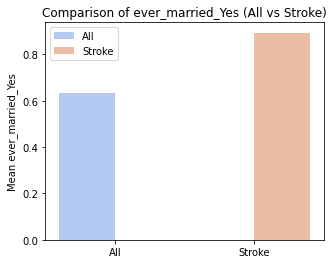

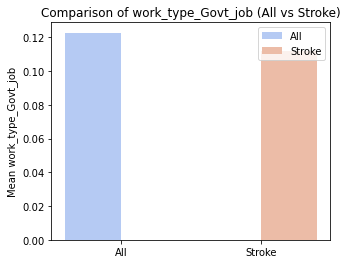

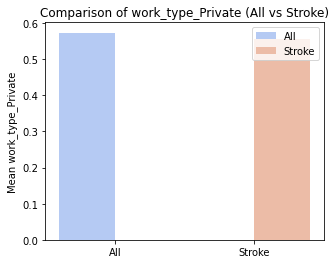

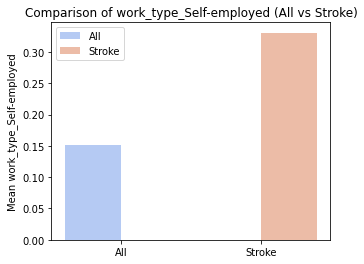

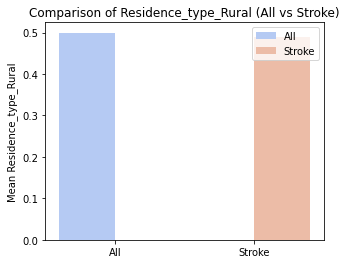

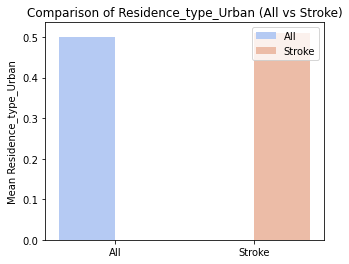

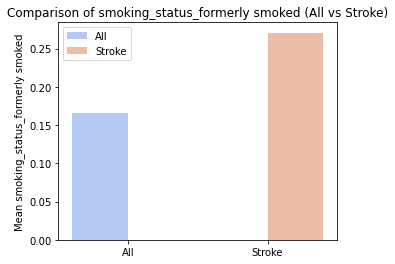

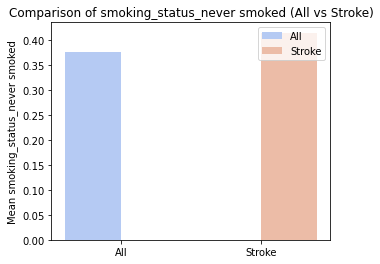

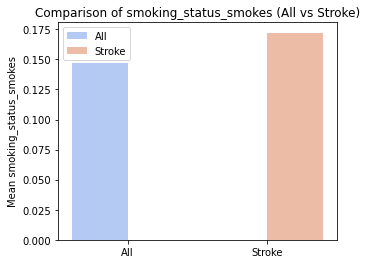

In [14]:
# Barplots for binary variables
for col in binary_cols:
    plt.figure(figsize=(5, 4))
    sns.barplot(x=['All', 'Stroke'], y=[df[col].mean(), df_stroke[col].mean()], palette='coolwarm', hue=['All', 'Stroke'])
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.ylabel(f'Mean {col}')
    plt.show()

[Partially ChatGPT, 2024. Prompt 3: Bar Plots for Binary Data](https://chatgpt.com/share/673091e6-fd34-8003-85e9-79fd69dbf738).

Proportionwise we can see that in the collumns `hypertension`, `heart_disease`, `work_type_Self-employed` and `smoking_status_formerly smoked`, people who had a stroke show a higher incidence of these factors. This could indicate that these collumns could be significantly relevant in relation to stroke risk. We will furter evaluate all the collumns to get a clearer understanding.

In [15]:
display(df.head())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,True,False,False,True,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,True,False,False,True,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,True,False,False,True,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,True,False,False,True,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,True,False,False,True,True,False,True,False,False,0


## Merging and Removing Redundant/Dummy Columns

In this step columns are deleted because their information has been merged or transformed into new columns, which simplifies the dataset. This process eliminates redundancy and reduces the number of columns, which can make the data easier to work with and less prone to overfitting in machine learning models.

**Gender:** 
The gender_Female, gender_Male, and gender_Other columns are merged into a single gender column (0 for Female, 1 for Male). The original columns are now redundant.

**Ever Married:**
ever_married_Yes and ever_married_No are combined into a single ever_married column (1 for Yes, 0 for No), making the original columns unnecessary.

**Residence Type:**
The one-hot encoded columns for Residence_type_Rural and Residence_type_Urban are merged into residence_type (0 for Rural, 1 for Urban), so the originals are deleted.

**Work Type:**
The work_type_Self-employed column is simplified into work_type_self_employed (1 for Self-employed, 0 otherwise). The original work type columns are no longer needed.

In [16]:
df = processor.preprocess_gender()
df = processor.preprocess_ever_married()
df = processor.preprocess_residence_type()
df = processor.preprocess_work_type()

display(df.head())


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
0,52709,30.0,0,0,63.60,33.3,False,False,True,0,1,0,0,0
1,72295,75.0,1,0,215.17,48.0,False,True,False,0,0,1,0,1
2,26451,15.0,0,0,135.22,19.0,False,True,False,0,1,0,0,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,0,1,1,1,1
4,69299,49.0,0,0,222.34,28.8,True,False,False,0,1,1,0,1


As we have removed the outliers, we can now show that the extreme outliers are not present anymore.

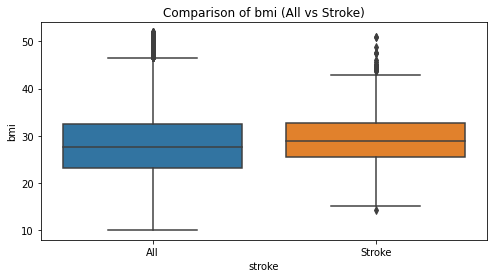

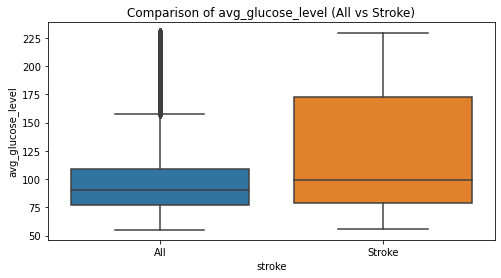

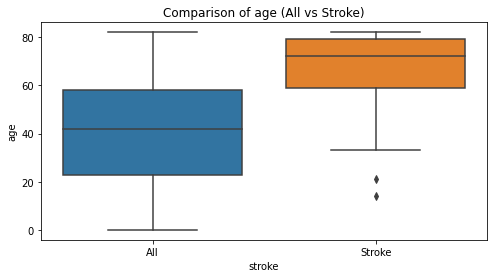

In [17]:
# Boxplot for continuous variables
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.xticks([0, 1], ['All', 'Stroke'])
    plt.ylabel(col)
    plt.show()

[Partially ChatGPT, 2024. Prompt 2: Boxplots by Stroke Status](https://chatgpt.com/share/67308e61-2548-8003-9a1d-3722fda414a9).

## Converting Nominal Data to Numerical Values (needed for ML)

In our dataset, we have three columns with continuous numerical values: `age`, `avg_glucose_level` and `bmi`. The other columns contain binary (*True/False*) data - if we are going to use these for Machine Learning we need to convert our df to numerical values only (1 for *True* and 0 for *False*).
While we're at it, we'll convert `age` from a *float* to an *integer*, as ages are typically represented as whole numbers.

In [18]:
df = processor.age_to_int()
df = processor.convert_bool_to_int()
display(df.head())


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
0,52709,30,0,0,63.60,33.3,0,0,1,0,1,0,0,0
1,72295,75,1,0,215.17,48.0,0,1,0,0,0,1,0,1
2,26451,15,0,0,135.22,19.0,0,1,0,0,1,0,0,0
3,65210,47,0,0,64.89,28.2,0,1,0,0,1,1,1,1
4,69299,49,0,0,222.34,28.8,1,0,0,0,1,1,0,1


## Correlation Heatmap with Storke


To better understand the relationship between each feature and the target variable (stroke), we use a heatmap to display the correlation values. This visualization helps us quickly identify which features have the strongest associations with stroke, which will help us in the feature selection. For our analysis, we will focus on features with a correlation above 0.01, as they are more likely to hold predictive value for stroke risk.

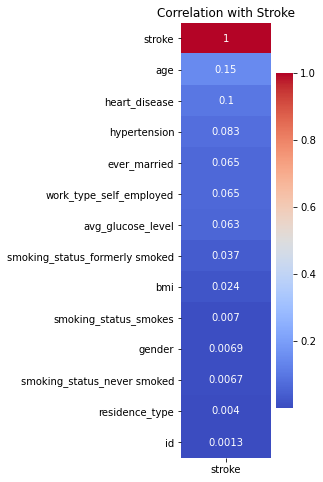

In [19]:
corr_df = df.corr()['stroke'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(2, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with Stroke')
plt.show()

The last four features: `smoking_status_smokes`, `gender`, `smoking_status_never smoked` and `residence_type` have correlations below 0.01. Because of this, they will unlkely contribute to the analysis and will be dropped. This will streamline our models and thus reduce noise.

## Data Cleaning

We will now look at the data (the continuous values) to see if all the data is logical and consistent

In [20]:
df_stroke = df[df['stroke'] == 1]
display(df_stroke.head())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
216,3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
231,43424,78,0,0,78.81,19.6,0,0,0,1,0,1,0,0
245,36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
283,23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1
289,11961,57,1,0,196.30,38.6,0,1,0,1,0,1,0,0


According to our dataset and based on the heatmap the collumns `gender`, `smoking_status_never smoked`, `smoking_status_smokes`, `residence_type` have almost no correlation to the collumn `stroke` - this is why we drop them:

In [21]:
columns_to_drop = [
    'gender',
    'smoking_status_never smoked', 
    'smoking_status_smokes',
    'residence_type'
]
df = processor.drop_columns(columns_to_drop)

display(df.head())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,stroke,ever_married,work_type_self_employed
0,52709,30,0,0,63.60,33.3,0,0,0,0
1,72295,75,1,0,215.17,48.0,0,0,1,1
2,26451,15,0,0,135.22,19.0,0,0,0,0
3,65210,47,0,0,64.89,28.2,0,0,1,1
4,69299,49,0,0,222.34,28.8,1,0,1,1


### Assumption
We might assume that people with a high BMI or high average glucose level are more likely to experience strokes. To test this, we will start by counting the total of people who had a stroke. Then, we will check how many of those had a high BMI, how many had high glucose levels and finally, how many had both - high BMI and high glucose levels.

In [22]:
df_stroke_and_overweight = df_stroke[df_stroke['bmi'] >= 25]

# Thresholds for high BMI and high average glucose level
high_bmi_threshold = 25
high_glucose_threshold = 125

# Total number of people who had a stroke
total_stroke_count = df_stroke['stroke'].sum()

# Number of people with high BMI who had a stroke
high_bmi_stroke_count = df_stroke[df_stroke['bmi'] >= high_bmi_threshold].shape[0]

# Number of people with high glucose who had a stroke
high_glucose_stroke_count = df_stroke[df_stroke['avg_glucose_level'] >= high_glucose_threshold].shape[0]

# Number of people with both high BMI and high glucose who had a stroke
high_bmi_glucose_stroke_count = df_stroke[(df_stroke['bmi'] >= high_bmi_threshold) & 
                                   (df_stroke['avg_glucose_level'] >= high_glucose_threshold)].shape[0]

print("Total number of people who had a stroke:", total_stroke_count)
print("Number of people with high BMI who had a stroke:", high_bmi_stroke_count)
print("Number of people with high glucose level who had a stroke:", high_glucose_stroke_count)
print("Number of people with both high BMI and high glucose level who had a stroke:", high_bmi_glucose_stroke_count)

Total number of people who had a stroke: 478
Number of people with high BMI who had a stroke: 382
Number of people with high glucose level who had a stroke: 159
Number of people with both high BMI and high glucose level who had a stroke: 139


In this dataset, we have 478 cases of people who had a stroke. When we look specificaly at those with a BMI over 25 (meaning they are overweight), we find that 382 of them had a stroke. Out of these, 159 also had a high glucose level and 139 had both a high BMI and high glucose. 

In conclusion this means that approx. 80% of overweight people (382/478) also suffered from a stroke according to this dataset.

To enhance the predictive power of our machine learning model, we will apply feature engineering to create new columns. This process uses our medical domain knowledge to inform the model about specific factors that may contribute to a higher stroke risk.

Johns Hopkins Medicine. (n.d.). Stroke. https://www.hopkinsmedicine.org/health/conditions-and-diseases/stroke retrieved on 06-11-2024.

According to the john Hopkins university there are several factors that can cause a stroke. Such as: 
- Older age (over the age 55 the chance of having a stroke doubles more.)
- High blood pressure
- Heart disease
- Diabetes
- Smoking
- Obesity

Because of these factors we have decided to feature engineer new collumns that combines the (possible) compounding factors, in order for our model to get a better insight of these possible interactions and improves it prediction results. 

In [23]:
df_stroke_and_hypertension = df_stroke[df_stroke['hypertension'] == 1]
display(df_stroke_and_hypertension)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
216,3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
245,36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
289,11961,57,1,0,196.30,38.6,0,1,0,1,0,1,0,0
616,6660,67,1,0,88.79,27.4,1,0,0,1,1,1,1,1
783,2326,67,1,0,179.12,28.1,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32941,53156,73,1,0,77.72,31.4,0,1,0,1,1,1,0,1
32947,36575,81,1,1,65.12,27.4,1,0,0,1,1,0,1,0
33137,34567,81,1,0,74.02,25.0,0,1,0,1,0,1,0,1
33147,20426,78,1,0,203.87,45.7,0,1,0,1,0,0,1,0


### Feature Engineering
We will apply some basic feature engineering. We will use our medical domain knowledge to create new collumns that tell our ML model which factors indicate a higher risk to have a stroke

Based on our dataset and the University of John Hopkins gathered data, if a patient is over 60 (please refer to our EDA boxplot), the chance to get a stroke is higher, but if a patient is over 60 and also has a disease like hypertension or a heart problem, the risk of a stroke is even higher. This is the reason why we make new columns that show the compounding effect of these combinations. 

In [24]:
df = processor.add_age_above_60()
df = processor.add_interaction_terms()
df = processor.categorize_bmi()
df = processor.categorize_glucose()

display(df[['age_above_60', 'age_above_60_hypertension', 'age_above_60_heart_disease', 'hypertension_former_smoker', 'bmi_category', 'glucose_category']].head())


,age_above_60,age_above_60_hypertension,age_above_60_heart_disease,hypertension_former_smoker,bmi_category,glucose_category
0,0,0,0,0,obese,normal
1,1,1,0,0,obese,diabetic
2,0,0,0,0,normal,normal
3,0,0,0,0,overweight,normal
4,0,0,0,0,overweight,diabetic


In [25]:
df = processor.encode_categories()
df = processor.drop_categorical_columns()


# Machine Learning Models

## Decision Tree

#### **Describe how this model works.**

A decision tree is a machine learning model that helps make decisions by splitting the data into smaller groups based on features in the data. Each questions (or decision) about the data leads to a branch and eventually a final decision is made. The process starts at the root node, where the models chooses the most important feature to split the data first. As the data gets split, additional questions are asked "Is the person with avg_glucose > 215.17?" and then in the last stage (the leaf nodes) a decision (=prediction) is made "Yes, the person will get a stroke.".

The tree decides which feature provides the best split using measures like Gini or Entropy. Through the usage of these both methods the uncertainty of our predictions should be reduced and the groups of data will become more homegenous.


#### **Describe the criteria on the basis of which the splits in the decision tree can be made.**

There are different criteria, based on which the data can be split - entropy, gini impurity, MSE, MAE, poisson deviance, huber loss, cross-entropy, friedman MSE, laplacian. As we are facing a classification problem and are dealing with categorical labels, we will be using the standart entropy and gini impurity measures to split the data.

As we are dealing with a binary classification problem (no strok=0, stroke=1) and the outcome is categorical (as we are predicting a class label stroke= 0 or 1 based on the other aformentioned features), we will firstly check which hyperparameters are best suited for our dataset. 

To find out which hyperparameter values are best suited and determine the best combination for our decision tree we will be using the GridSearchCV to systematicly test a wide range of hyperparameter values and determine the best combinations for our model.

In [26]:
from sklearn.model_selection import GridSearchCV

X = df.drop(columns=['stroke']) 
y = df['stroke']  

# Random Undersampling for balance
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# max depth -> controlls the depth of the tree to avoid overfitting.
# We will try with a shallow tree(5), a slightly deeper one(10) and a relatively deep tree (15)
# min_samples_split -> controls the minimum number of samples needed to split a node
# Higher values (10, 20) prevent the tree from growing too deep.
# min_samples_leaf -> controls the minimum number of samples in a leaf node
# Larger leaf sizes (5, 10) promote generalization and reduce overfitting
# criterion -> the function used to measure the quality of a split (Gini or Entropy)
# gini is faster, while entropy can get better results for complex data.
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=kfold, scoring='f1')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f'Best hyperparameters values are: {best_params}')

Best hyperparameters values are: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}


Although 'gini' is the best hyperparameter according to Grindsearch, 'enthropy' is better for complex datasets and after several tries it gave the best result on Kaggle and that is why we will be using it.

#### **Explain what 'pruning' is, describe what forms of it have been applied / Explain the relationship between 'pruning' and 'underfitting'**

Prunning is the process of removing unnecessary branches/nodes from the decision tree to make it simpler and prevent the risk of overfitting the data. There are 2 main types of prooning, pre-prunning this is where we adjusted the max_depth, min_samples_split and min_samples_leaf. In doing so we prevented our tree from growing too large and capturing unnecessary details form the training data. Underfitting on the other hand happens, when the model is too simple to capture specific patterns in the data. Meaning - that if we prune too much our decision tree, by setting for example a overly strict min_samples_split of 50, the tree might become too shallow and fail to learn important relationships, which would lead to underfitting. 


In [27]:

best_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

best_clf.fit(X_train, y_train)

y_pred_best = best_clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.73      0.86      0.79        90
           1       0.85      0.72      0.78       102

    accuracy                           0.78       192
   macro avg       0.79      0.79      0.78       192
weighted avg       0.79      0.78      0.78       192



In [28]:
# Load and preprocess new test data
def clean_data(dataframe, columns_to_drop, reference_columns):
    processor = DataPreprocessor(dataframe)
    cleaned_data = processor.preprocess(columns_to_drop, reference_columns)
    return cleaned_data

columns_to_drop = ['gender', 'smoking_status_never smoked', 'smoking_status_smokes', 'residence_type']

new_data = pd.read_csv('test.csv')  
reference_columns = X.columns  # Reference columns from the training data
X_new = clean_data(new_data, columns_to_drop, reference_columns)

# Make predictions
y_new_pred = best_clf.predict(X_new)

# Merging DataFrames
output_df = pd.DataFrame(y_new_pred, columns=['stroke'])
merged_df = pd.merge(X_new[['id']], output_df[['stroke']], left_index=True, right_index=True)

# Saving predictions to csv
merged_df.to_csv('predictions_decision_tree_classifier_3.csv', index=False)

## Logistic Regression 

Logistic regression is a statistical model that is used to make a binary decision. This means that it helps to distinguish between two possible outcomes, e.g. in our case, it is about predicting whether a person will suffer a stroke (1) or not (0) based on certain information (e.g. age, glucose level, etc).
#### **How does the model work?**

**Inputs:** We have several characteristics (also called features), such as age, glucose level and BMI. These values are numbers and are given as inputs to the model.

**Calculating the weighting:** Each characteristic has a certain importance, which is determined by so-called "weights". The model multiplies each characteristic by a weight and adds everything together. The result is a number that roughly shows how likely it is that the result is 1 or 0.

**Sigmoid function:** This number is then converted into a probability between 0 and 1 using the logistic function (also known as the sigmoid function). This function ensures that all values fall into the range 0 to 1, which corresponds to a probability.

$$ \text{Sigmoid-Function} = \frac{1}{1 + e^{-z}} $$

*z = the sum of the weighted characteristics*

[ChatGPT, 2024. Prompt 4: Display Sigmoid and Log-Loss](https://chatgpt.com/share/67309da4-c784-8003-96b6-36b3d65d8e81).

#### **What is the loss function?**

The loss function measures how well or poorly the model works. The smaller the loss, the better the model works. In logistic regression, we use a special loss function called "Log-Loss".
E.g. if the model predicts for a person that the probability of a stroke is 90%, but the person does not have a stroke, this is a bad prediction and the **loss is high**.
If the model predicts 90% probability for a person and the person actually has a stroke, then the **loss is small** because the prediction was good.
The goal is to minimize the loss for the entire model.

$$ \text{Log-Loss} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] $$

\( y_i \) *represents the actual labels (either 0 or 1).* 

\( p_i \) *the predicted probability for class 1.*


[ChatGPT, 2024. Prompt 4: Display Sigmoid and Log-Loss](https://chatgpt.com/share/67309da4-c784-8003-96b6-36b3d65d8e81).

#### **What is gradient descent in this context?**

Gradient Descent is the method we use to find the best weights for our logistic regression model. The goal is to **minimize the loss function (log-loss)**, which measures how far off the model’s predictions are from the actual values.

**Simple calculation example:**
Let’s say we are predicting whether someone has a stroke based on just age. We start with a random weight, say $\theta = 0.5$, for age.

For one data point, say a 60-year-old person, we calculate $z$, the weighted sum of the input:
$$
z = \theta \times \text{age} = 0.5 \times 60 = 30
$$

Then we apply the **sigmoid function** to get the probability (prediction):

$$
h_\theta(x) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-30}} \approx 1
$$

So, our model predicts a probability close to 1 (very likely stroke).

**Next steps:**

1. **Calculating the loss:**
If the actual outcome is $y = 0$ (no stroke), we calculate the loss using the log-loss function:

$$
J(\theta) = -[y \log(h_\theta(x)) + (1 - y) \log(1 - h_\theta(x))]
$$

Since $y = 0$, the loss becomes very large because the model predicted the wrong outcome:

$$
J(\theta) \approx -[0 \times \log(1) + (1 - 0) \log(0)] = \infty
$$

2. **Calculating the gradient:**
The gradient shows how much to adjust $\theta$. The gradient for $\theta$ is:

$$
\frac{\partial J(\theta)}{\partial \theta} = (h_\theta(x) - y) \times \text{age}
$$

which equals:

$$
\frac{\partial J(\theta)}{\partial \theta} = (1 - 0) \times 60 = 60
$$

2. **Updating the weights:**
We adjust $\theta$ using the gradient and a learning rate $\alpha$ (say $\alpha = 0.01$):

$$
\theta := \theta - \alpha \times \frac{\partial J(\theta)}{\partial \theta}
$$

So, the new value of $\theta$ becomes:

$$
\theta := 0.5 - 0.01 \times 60 = -0.1
$$

#### **What are the forms of regularization that apply to this model?**

There are two main forms of regularization that apply to logistic regression:

1. **L1 Regularization ("Lasso")**:
- This type of regularization adds a penalty to the model based on the absolute values of the coefficients. It tends to push some coefficients to zero, effectively removing less important features from the model. This helps with feature selection.

- The penalty term for L1 regularization is:

$$ \text{Penalty} = \lambda \sum |\theta_j| $$

2. **L2 Regularization ("Ridge")**:
- L2 regularization adds a penalty proportional to the square of the coefficients. Unlike L1, it doesn’t eliminate features but instead reduces the magnitude of all the coefficients, making the model less sensitive to small variations in the data.

- The penalty term for L2 regularization is:

$$ \text{Penalty} = \frac{\lambda}{2} \sum \theta_j^2 $$

Both of these methods help reduce overfitting by preventing the model from becoming too complex.

#### **How does regularization relate to overfitting?**

Overfitting happens when a model learns not just the meaningful relationships between the features and the target but also the noise (e.g. errors, outliers,..) in the training data. Regularization helps prevent this by penalizing large coefficients.

- **L1 regularization** eliminates unimportant features by pushing their coefficients to zero, reducing the complexity of the model.
- **L2 regularization** keeps all the features but reduces the size of the coefficients, making the model simpler and less prone to fitting the noise in the training data.

Simply put, regularization helps the model perform better on new, unseen data.

#### **At which hyperparameters does the model give the best results?**

The main hyperparameter for regularization is *C*. It controls how strong the regularization is. A **larger *C* value means less regularization**, so the model can fit the training data more closely. A **smaller *C* value increases regularization**, shrinking the coefficients and helping prevent overfitting.

To find the best C-value, you can either use cross-validation tools like *GridSearchCV* to automatically find the optimal value or manually experiment with different values like *C= 0.1, 1.0, 10, 100,..* and see which one gives the best results for your model.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Adding regularization: L2 & C=1.0 are the defaults
lr = LogisticRegression(penalty='l2',C=1.0, class_weight='balanced') # "class weighting" technique for imbalanced data
lr.fit(X_train, y_train)

#Making predictions
y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79        90
           1       0.82      0.80      0.81       102

    accuracy                           0.80       192
   macro avg       0.80      0.80      0.80       192
weighted avg       0.80      0.80      0.80       192



In [30]:
# Load and preprocess new test data
def clean_data(dataframe, columns_to_drop, reference_columns):
    processor = DataPreprocessor(dataframe)
    cleaned_data = processor.preprocess(columns_to_drop, reference_columns)
    return cleaned_data

new_data = pd.read_csv('test.csv')  
columns_to_drop = ['gender', 'smoking_status_never smoked', 'smoking_status_smokes', 'residence_type']
reference_columns = X.columns  # Reference columns from the training data
X_new = clean_data(new_data, columns_to_drop, reference_columns)

# Make predictions
y_new_pred = lr.predict(X_new)

# Merging DataFrames
output_df = pd.DataFrame(y_new_pred, columns=['stroke'])
merged_df = pd.merge(X_new[['id']], output_df[['stroke']], left_index=True, right_index=True)

# Saving predictions to csv
merged_df.to_csv('predictions_logistic_regression.csv', index=False)

/Users/ayman/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## K-Nearest Neighbors (KNN)

#### **Describe how this model works.**

K-Nearest Neighbors (KNN) is a machine learning model used for both classification and regression tasks. The model classifies a new data point by identifying the 'k' data points in the training set that are closest to it, based on a chosen distance metric. Once these neighbors are identified, the KNN model makes a prediction based on the majority label among the neighbors for classification tasks. For regression tasks, the average of the neighboring data points is often used for prediction.

KNN's prediction process looks like this in our stroke prediction scenario: "Is the individual similar in age, BMI, and glucose level to other patients who have had a stroke?" If most of their nearest neighbors have experienced strokes, then the KNN model might predict that this individual is also at risk. By identifying and grouping similar data points, KNN helps provide insights into how close relationships in data influence outcomes.



#### **Euclidean or Manhattan**

KNN typically uses distance measures like Euclidean or Manhattan distance, with Euclidean distance (straight-line distance between points) being common in most implementations, especially when features are scaled similarly. Manhattan distance, which calculates the sum of absolute differences across dimensions, can be used when features are unevenly scaled.

#### **Importance of Standardization**

Standardization, or scaling, is crucial for KNN because the model relies on distances between data points to make predictions. If the features in the dataset have different units or ranges, they will disproportionately influence the distance calculation. For instance, if age ranges from 20 to 90, while glucose levels range from 70 to 200, the differences in glucose levels would dominate the distance calculation, making the model more sensitive to that feature.

The KNN model has several hyperparameters that can be tuned to achieve the best results:

Number of Neighbors (k): This is the primary hyperparameter in KNN. A small k value can make the model sensitive to noise, while a large k value smooths predictions but may overlook subtle patterns. Grid search or cross-validation can help identify the optimal k value for a specific dataset.

Distance Metric: Choosing between Euclidean, Manhattan, or other distance metrics can also impact model performance. Sometimes experimenting with different metrics is necessary to find the best fit for the data.

Weighting: In some cases, KNN can assign different weights to neighbors based on their distance to the query point. Closer neighbors can be weighted more heavily, which may improve accuracy, especially when the number of neighbors (k) is high.

In [31]:
X = df.drop(columns=['stroke']) 
y = df['stroke']  

#random undersampling for balancing the unbalanced data
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameter grid for KNN
# n_neighbors: the number of neighbors to consider (smaller values capture more local patterns)
# weights: either uniform weighting or distance-based weighting
# metric: distance metric, with 'euclidean' and 'manhattan' as common choices
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],  
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean', 'manhattan']  
}

knn = KNeighborsClassifier()
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=stratified_kfold, scoring='f1', n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train)

best_params_knn = grid_search_knn.best_params_
print(f'Best hyperparameter values for KNN are: {best_params_knn}')


Best hyperparameter values for KNN are: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


In [32]:
# Initialize KNN with the best hyperparameters and train on scaled data
best_knn = KNeighborsClassifier(**best_params_knn)
best_knn.fit(X_train_scaled, y_train)

# Predict on the scaled test data
y_pred = best_knn.predict(X_test_scaled)

# Generate and display classification report
report = classification_report(y_test, y_pred)
print("Classification Report for KNN Model with Best Hyperparameters:")
print(report)

Classification Report for KNN Model with Best Hyperparameters:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77        90
           1       0.82      0.75      0.78       102

    accuracy                           0.78       192
   macro avg       0.78      0.78      0.78       192
weighted avg       0.78      0.78      0.78       192



In [33]:
# Load and preprocess new test data
def clean_data(dataframe, columns_to_drop, reference_columns):
    processor = DataPreprocessor(dataframe)
    cleaned_data = processor.preprocess(columns_to_drop, reference_columns)
    return cleaned_data

new_data = pd.read_csv('test.csv')  
columns_to_drop = ['gender', 'smoking_status_never smoked', 'smoking_status_smokes', 'residence_type']
reference_columns = X.columns  # Reference columns from the training data
X_new = clean_data(new_data, columns_to_drop, reference_columns)

# Make predictions
y_new_pred = best_knn.predict(X_new)


# Merging DataFrames
output_df = pd.DataFrame(y_new_pred, columns=['stroke'])
merged_df = pd.merge(X_new[['id']], output_df[['stroke']], left_index=True, right_index=True)

# Saving predictions to csv
merged_df.to_csv('predictions_knn.csv', index=False)

/Users/ayman/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


## Ensembles

#### **Describe the operation of the 3 ensembles mentioned.**
*Use at least the terms "sequential" and "parallel".*

Random Forest: Random Forest is an ensemble method based on "bagging" (bootstrap aggregation) (a statistical technique method used to reduce variance within a noisy data set and by doing so reduce overfitting of the data. In this mathod a random sample of data in a training set is used with a so called replacement technique, which means it uses samling with replacements to make the selection procedure completely random, and create multiple datasets for training.). It builds multiple decision trees in parallel, each trained on a randomly sampled subset of the data, and averages their predictions. This **parallel** structure makes training faster and reduces the risk of overfitting. 

Gradient Boosted Decision Trees is a method  based on "boosting," where decision trees are built sequentially, each tree attempting to correct the errors of the previous one. As the building of the trees is **sequential** - this method is slower to train compared to Random Forest but can result in a more accurate model by balancing the results of the model. 

XGBoost is an enhanced gradient boosting algorithm, because it has some optimisations that gradient Boosting doesn't offer. It applies the "boosting" method in a similar way, incorporating regularization to avoid overfitting and offering faster processing. Since it builds trees **sequentially** just like Gradient Boosting, it takes more time to train.

#### **Explain which ensembles need a relatively large amount of training time and which ones need little time.**

 Random Forest trains relatively quickly because it builds trees in parallel, making it suitable for faster results.Gradient Boosted Decision Trees and XGBoost are slower since they follow a sequential boosting approach, where each tree depends on the previous one, requiring more more resources, when they are run more training time and are because of that slower.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
undersampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

# Random Forest
param_grid_rf = {
    'n_estimators': [80, 120, 280],
    'max_depth': [5, 20, 30, None],
    'min_samples_split': [2, 30, 40],
    'min_samples_leaf': [1, 15, 17],
    'criterion': ['gini', 'entropy']
}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=kfold,
    scoring='f1',
    n_jobs=-1
)
grid_search_rf.fit(X_train_resampled, y_train_resampled)
best_rf_model = grid_search_rf.best_estimator_
best_rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = best_rf_model.predict(X_test)
print("Random Forest Best Parameters:", grid_search_rf.best_params_)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=1))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Gradient Boosted Decision Trees
param_grid_gbdt = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_search_gbdt = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gbdt,
    cv=kfold,
    scoring='f1',
    n_jobs=-1
)
grid_search_gbdt.fit(X_train_resampled, y_train_resampled)
best_gbdt_model = grid_search_gbdt.best_estimator_
best_gbdt_model.fit(X_train_resampled, y_train_resampled)
y_pred_gbdt = best_gbdt_model.predict(X_test)
print("\nGradient Boosted Decision Trees Best Parameters:", grid_search_gbdt.best_params_)
print("\nGradient Boosted Decision Trees Classification Report:")
print(classification_report(y_test, y_pred_gbdt, zero_division=1))
print("Accuracy:", accuracy_score(y_test, y_pred_gbdt))

# XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=kfold,
    scoring='f1',
    n_jobs=-1
)
grid_search_xgb.fit(X_train_resampled, y_train_resampled)
best_xgb_model = grid_search_xgb.best_estimator_
best_xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = best_xgb_model.predict(X_test)
print("\nXGBoost Best Parameters:", grid_search_xgb.best_params_)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=1))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))


## SVM (Support Vector Machine)

#### **What is SVM?**

SVM stands for Support Vector Machine. It's an supervised learning algorithm that's used for classification. it tries to find the best line (or hyperplane in an higher dimensions) that divides data into different categories/classes. For example, if you have two groups of data points, SVM tries to draw a line that divides them as clearly as possible.

#### **How does SVM find the best line?**

SVM focuses on maximizing the margin, which is the space between the dividing line and the closest data points from each class. The closest points are called **support vectors** .They support/define the place of the dividing line.

SVM finds this line/hyperplane by solving the mathematical problem where it minimizes the size of the weights (**w**) while making sure each data point is classified with some margin. The formula is:

$$
\frac{1}{2} ||w||^2
$$

This mean that SVM's goal is to make the weights to be as small as possible, while still separating the groups clearly.

#### **What are kernels and how do they work?**

In some cases, you can't separate data with a straight line (or (hyperplane) plane). In these cases, SVM uses something called the **kernel trick**. A kernel is a function that transforms the data into an higher-dimensional space where it can be separated. Some of the most used kernels are:

1. **Linear Kernel**: The standard setting, works when data is linearly separable.
2. **Polynomial Kernel**: Adds a extra layer of by considering polinomial relationships between the data points.
3. **RBF (Radial Basis Function) Kernel**: Usefull for when the data isn't linearly or polynomial separable, creates boundaries that can be used to identify groups.

#### **How does SVM handle mistakes?**
@TODO SHANIL: Maybe add a chatgpt appendix for hinge loss function. if you do, please one time below the formula and one in the end in appendix

SVM uses a loss function to deal with data points that are hard to separate. It is called the **Hinge Loss**, and it penalizes (data)points that are misclassified or are too close to the boundary:

$$
L(y_i, f(x_i)) = \max(0, 1 - y_i \cdot f(x_i))
$$

if a point is on the correct side and far enough from the line, then there is no penalty but if its on the wrong side or too close, the loss function adds a penalty, so the model adjusts to work better.

#### **What is Regularization?**

Regularization helps avoid the model from overfitting (like fitting too closely to the training data while giving bad scores on unseen data). In SVM, we add a regularization term with a parameter called **C** to balance the simplicity and accuracy.

1. **L2 Regularization**: This reduces the size of the weights **w** but doesn't make any weights zero. It keeps all features/collumns but reduces their impact. The regularized objective function is:

$$
\min \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \max(0, 1 - y_i \cdot (w^T x_i + b))
$$

Higher values of **C** allow for less mistakes, making the model accurate but also more complex (and might  possibly overfit).

#### **Tuning Hyperparameters to improve the model**

SVM has some hyperparameters that can be tweaked to improve performance:

1. **C (Regularization Parameter) **: Controls the tradeoff between having a simple boundary and correctly classifying training examples.
2. **Kernel Choice and it's parameters**:
   - For RBF, **gamma** controls how closely the model fits the data. Higher gamma values makes a more flexible boundary but increases the chance of overfitting.
   - For Polynomial kernels, **degree** sets the complexity.
 

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# use borderline-smote for oversampling
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X_train, y_train)

# for further balancing we will be using the random undersampler from the imblearn library
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_resampled, y_resampled)

# we will further normalize the features using RobustScaler
scaler = RobustScaler()
X_resampled = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf', class_weight='balanced', probability=True)

# refined parameter space for hyperparameter optimization
param_space_refined = {
    'C': Real(1e-2, 10, prior='log-uniform'),  # Narrowed range for 'C'
    'gamma': Real(1e-3, 1e-1, prior='log-uniform')  # Narrowed range for 'gamma'
}

# ese BayesSearchCV for hyperparameter optimization with refined search space
bayes_search_refined = BayesSearchCV(
    estimator=model,
    search_spaces=param_space_refined,
    n_iter=10,  # Reduced number of iterations for faster optimization
    cv=3,  # Cross-validation with 3 folds to speed up the tuning
    scoring=make_scorer(f1_score),  # Optimize for F1 score
    random_state=42,
    n_jobs=-1
)

bayes_search_refined.fit(X_resampled, y_resampled)
# predictions
y_pred = bayes_search_refined.best_estimator_.predict(X_test)
y_pred_proba = bayes_search_refined.best_estimator_.predict_proba(X_test)[:, 1]

# evaluate the model
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

## Self Ensembles

An ensemble model combines predictions from multiple ML models to get better results than the individual models. By integrating the strengths of different models, a ensemble can reduce the risk of overfitting or underfitting specific patterns within the data.

In this code, a Voting Classifier ensemble is used, which combines three different classifiers: a Decision Tree, Gradient Boosting, and Support Vector Machine (SVM). Soft voting is applied here, meaning each model outputs a probability for each class, and the probabilities are averaged across all models. The class with the highest average probability is selected as the final prediction. Soft voting is effective when models have varying confidence levels, as it takes into account each model's probability estimate rather than just the predicted class, leading to smoother, more balanced results.


Each model in the ensemble brings its unique strengths:

    Decision Tree Classifier: This model is intuitive and interpretable, providing insights into feature importance and decision paths. It can capture non-linear patterns and handle imbalanced datasets when combined with class_weight='balanced'.

    Gradient Boosting Classifier: Gradient Boosting is a goof performer on structured data. It improves accuracy by sequentially learning from previous errors. This model is well-suited for fine-tuning and generally achieves good performance on complex tasks/data.

    Support Vector Machine (SVM): SVM is effective for classification tasks, especially when using a kernel (e.g., radial basis function, rbf) that can capture non-linear relationships in the data. With class_weight='balanced', the SVM model adjusts its influence on minority classes, which is crucial in imbalanced datasets like this one.

The combination of these models ensures that the ensemble leverages the interpretability of the Decision Tree, the precision of Gradient Boosting, and the robustness of SVM. Together, they balance each other's weaknesses and produce a more accurate final prediction.

In [ ]:
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply undersampling to balance the training dataset
undersample = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersample.fit_resample(X_train, y_train)

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_resampled, y_resampled)

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_resampled, y_resampled)

# Support Vector Machine (SVM)
# Scale the features for SVM
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_resampled_scaled, y_resampled)

# Ensemble model using VotingClassifier
ensemble_model = VotingClassifier(
    estimators=[
        ('decision_tree', dt_model),
        ('gradient_boosting', gb_model),
        ('svm', svm_model)
    ],
    voting='soft'  # Use 'soft' voting to average the probabilities
)
ensemble_model.fit(X_resampled_scaled, y_resampled)

# Make predictions with the ensemble model
ensemble_predictions = ensemble_model.predict(X_test_scaled)
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)

print(f"Ensemble Model Accuracy: {ensemble_accuracy}")
print(classification_report(y_test, ensemble_predictions)) 

# Conclusion and Advice

**Which models performs best? Why? At what parameters? (Based on the provided dataset(not the Kaggle dataset!))**

The logistic regression achieved the best result of all the models with an F1-score of 81% for correctly predicting if a person will have a stroke and 79% if they will not, which is the best result of all the models as clearly seen in the table. Let's analyse the four different metrics based on which we decided that Logistic regression is the best chosen model. The precision measures how many of the predicted strokes are actually correct, ensuring a minimum number of false alarms. Recall measures how many of the actual stroke cases are correctly identified, minimizing false diagnoses of heartstrokes. The F1 score is a harmonic mean of precision and recall and provides a balanced representation between false positives and false negatives. The accuracy of 80% reflects the overall reliability of the model in making correct predictions, which solidifies logistic regression as the most best model for stroke prediction based on our made analysis.

**A model's performance matters. What other considerations play a role, besides the performance of the model, to make the right choice for a model? Which model do you recommend to doctors to use? Explain why.**

Although, there are different considerations that have to be made, we would recommend using the logistic regression, based on the dataset we worked with and its results, but also because - Logistic Regression is an algorithm widely used in the health industry, it can handle various types of input variables, provides clear interpretable results. Logistic regression is also computationally lightweight, which would allow it to be easily used upon live data of systems in hospitals. Those are the reason we would suggest using Logistic Regression to medical professionals.

- *Abbreviations:
    Gradient Boosted Decision Trees (GBDT)


| Model - Locally      | Precision  | Recall     | F1-Score   | Accuracy | Best Parameters                                                |
|----------------------|------------|------------|------------|----------|----------------------------------------------------------------|
| Decision Tree        | 0.73/0.85  | 0.86/0.72  | 0.79/0.78  | 0.78     |                                                                |
| Logistic Regression  | 0.78/0.82  | 0.80/0.80  | 0.79/0.81  | 0.80     |                                                                |
| KNN                  | 0.74/0.82  | 0.81/0.75  | 0.77/0.78  | 0.78     |                                                                |
| Random Forest        | 1.00/0.04  | 0.71/0.86  | 0.83/0.07  | 0.71     |                                                                |
| GBDT                 | 1.00/0.03  | 0.63/0.95  | 0.78/0.06  | 0.64     |                                                                |
| XGBoost              | 1.00/0.04  | 0.71/0.86  | 0.83/0.07  | 0.71     |                                                                |
| SVM                  | 0.99/0.04  | 0.89/0.27  | 0.94/0.06  | 0.88     |                                                                |
| Self Ensembles       | 1.00/0.04  | 0.72/0.84  | 0.84/0.07  | 0.72     |                                                                |

@TODO: Michael delete these entries and add yours here please:

| Model - Kaggle      | Precision  | Recall     | F1-Score   | Accuracy | Best Parameters                                                |
|----------------------|------------|------------|------------|----------|----------------------------------------------------------------|
| Decision Tree        | 0.73/0.85  | 0.86/0.72  | 0.79/0.78  | 0.78     |                                                                |
| Logistic Regression  | 0.78/0.82  | 0.80/0.80  | 0.79/0.81  | 0.80     |                                                                |
| KNN                  | 0.74/0.82  | 0.81/0.75  | 0.77/0.78  | 0.78     |                                                                |
| Random Forest        | 1.00/0.04  | 0.71/0.86  | 0.83/0.07  | 0.71     |                                                                |
| GBDT                 | 1.00/0.03  | 0.63/0.95  | 0.78/0.06  | 0.64     |                                                                |
| XGBoost              | 1.00/0.04  | 0.71/0.86  | 0.83/0.07  | 0.71     |                                                                |
| SVM                  | 0.99/0.04  | 0.89/0.27  | 0.94/0.06  | 0.88     |                                                                |
| Self Ensembles       | 1.00/0.04  | 0.72/0.84  | 0.84/0.07  | 0.72     |                                                                |


# Appendix

ChatGPT, 2024. Prompt 1: Code Documentation Request.<br>
https://chatgpt.com/share/67308835-1074-8000-bcb6-2c183bcaecd0. @TODO MICHAL: correct this if you changed anything above

ChatGPT, 2024. Prompt 2: Boxplots by Stroke Status.<br>
https://chatgpt.com/share/67308e61-2548-8003-9a1d-3722fda414a9.

ChatGPT, 2024. Prompt 3: Bar Plots for Binary Data.<br>
https://chatgpt.com/share/673091e6-fd34-8003-85e9-79fd69dbf738.

ChatGPT, 2024. Prompt 4: Display Sigmoid and Log-Loss.<br>
https://chatgpt.com/share/67309da4-c784-8003-96b6-36b3d65d8e81.